# EDA — `lexdata.inasistencia_alimentaria`
Fiscalía SPOA · incumplimiento obligación alimentaria

## 0 · Setup

In [1]:
import sys
!{sys.executable} -m pip install psycopg2-binary


[notice] A new release of pip is available: 23.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import sys
!{sys.executable} -m pip install sqlalchemy python-dotenv


[notice] A new release of pip is available: 23.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# ── Dependencias ────────────────────────────────────────────────────────────
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sqlalchemy import create_engine, text
from dotenv import load_dotenv

# ── Estilo ──────────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120

# ── Conexión PostgreSQL via .env ─────────────────────────────────────────────
load_dotenv()  # carga .env desde la carpeta del notebook
DB_URL = (
    f"postgresql+psycopg2://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}"
    f"@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}"
)
engine = create_engine(DB_URL)

def sql(query, **kwargs):
    with engine.connect() as con:
        return pd.read_sql(text(query), con, **kwargs)

print("✅ Conexión lista:", DB_URL.split("@")[-1])


✅ Conexión lista: localhost:5432/lexdata


## 1 · Vista general

In [4]:
df = sql("SELECT * FROM lexdata.inasistencia_alimentaria")
print(f"Shape: {df.shape}")
df.head(10)


Shape: (112, 8)


,id,municipio,departamento,anio,cantidad,tipo_ciclo,fuente,created_at
0,1,ANORI,ANTIOQUIA,None,1.0,INASISTENCIA,Fiscalia — Inasistencia Alimentaria,2026-05-25 14:21:48.403966
1,2,BRICENO,ANTIOQUIA,None,1.0,INASISTENCIA,Fiscalia — Inasistencia Alimentaria,2026-05-25 14:21:48.403966
2,3,CACERES,ANTIOQUIA,None,1.0,INASISTENCIA,Fiscalia — Inasistencia Alimentaria,2026-05-25 14:21:48.403966
3,4,ITUANGO,ANTIOQUIA,None,1.0,INASISTENCIA,Fiscalia — Inasistencia Alimentaria,2026-05-25 14:21:48.403966
4,5,TARAZA,ANTIOQUIA,None,1.0,INASISTENCIA,Fiscalia — Inasistencia Alimentaria,2026-05-25 14:21:48.403966
5,6,ARAUQUITA,ARAUCA,None,1.0,INASISTENCIA,Fiscalia — Inasistencia Alimentaria,2026-05-25 14:21:48.403966
6,7,CANTAGALLO,BOLIVAR,None,1.0,INASISTENCIA,Fiscalia — Inasistencia Alimentaria,2026-05-25 14:21:48.403966
7,8,SAN PABLO,BOLIVAR,None,1.0,INASISTENCIA,Fiscalia — Inasistencia Alimentaria,2026-05-25 14:21:48.403966
8,9,SANTA ROSA DEL SUR,BOLIVAR,None,1.0,INASISTENCIA,Fiscalia — Inasistencia Alimentaria,2026-05-25 14:21:48.403966
9,10,BELEN DE LOS ANDAQUIES,CAQUETA,None,1.0,INASISTENCIA,Fiscalia — Inasistencia Alimentaria,2026-05-25 14:21:48.403966


In [5]:
df.describe(include="all").T


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
id,112.0,NaN,NaN,NaN,56.5,1.0,28.75,56.5,84.25,112.0,32.475632
municipio,112,55,PUERTO RICO,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
departamento,112,14,CAQUETA,18,NaN,NaN,NaN,NaN,NaN,NaN,NaN
anio,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cantidad,112.0,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0,1.0,0.0
tipo_ciclo,112,1,INASISTENCIA,112,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fuente,112,1,Fiscalia — Inasistencia Alimentaria,112,NaN,NaN,NaN,NaN,NaN,NaN,NaN
created_at,112,NaN,NaN,NaN,2026-05-25 14:22:27.917852160,2026-05-25 14:21:48.403966,2026-05-25 14:21:48.403965952,2026-05-25 14:22:27.917852160,2026-05-25 14:23:07.431738112,2026-05-25 14:23:07.431738,NaN


## 2 · Nulos

In [6]:
nulos = df.isnull().sum().rename("nulos")
pct   = (df.isnull().mean() * 100).round(2).rename("pct_%")
display(pd.concat([nulos, pct], axis=1))


,nulos,pct_%
id,0,0.0
municipio,0,0.0
departamento,0,0.0
anio,112,100.0
cantidad,0,0.0
tipo_ciclo,0,0.0
fuente,0,0.0
created_at,0,0.0


## 4 · Municipios afectados

Municipios únicos: 55


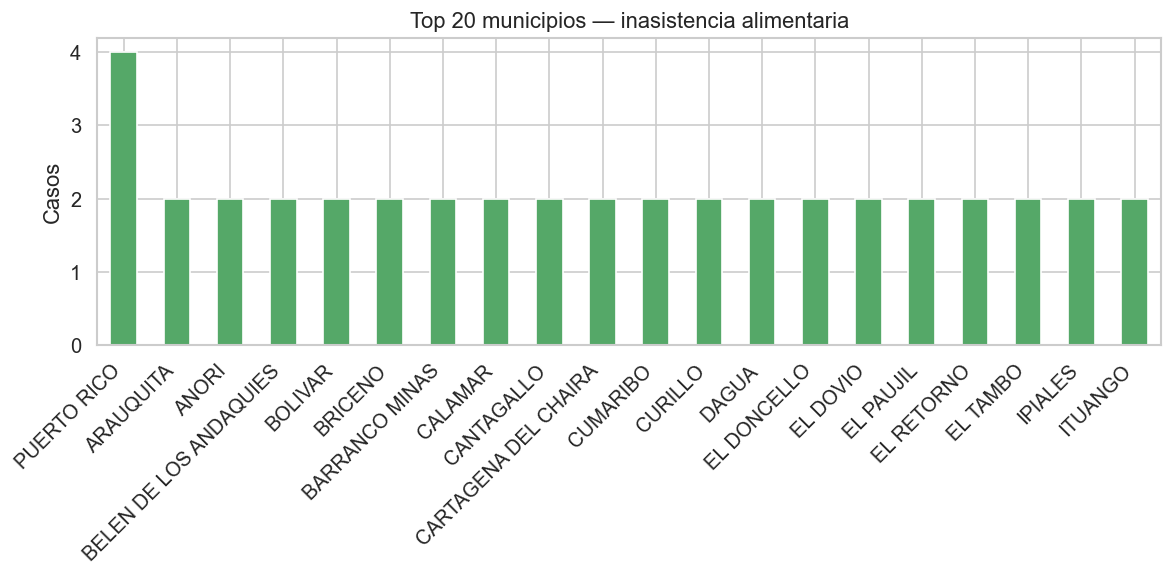

In [8]:
mun_cnt = df.groupby("municipio")["cantidad"].sum().sort_values(ascending=False)
print(f"Municipios únicos: {len(mun_cnt)}")

fig, ax = plt.subplots(figsize=(10, 5))
mun_cnt.head(20).plot(kind="bar", ax=ax, color="#55A868")
ax.set_title("Top 20 municipios — inasistencia alimentaria")
ax.set_xlabel(""); ax.set_ylabel("Casos")
plt.xticks(rotation=45, ha="right")
plt.tight_layout(); plt.show()


## 5 · Por departamento

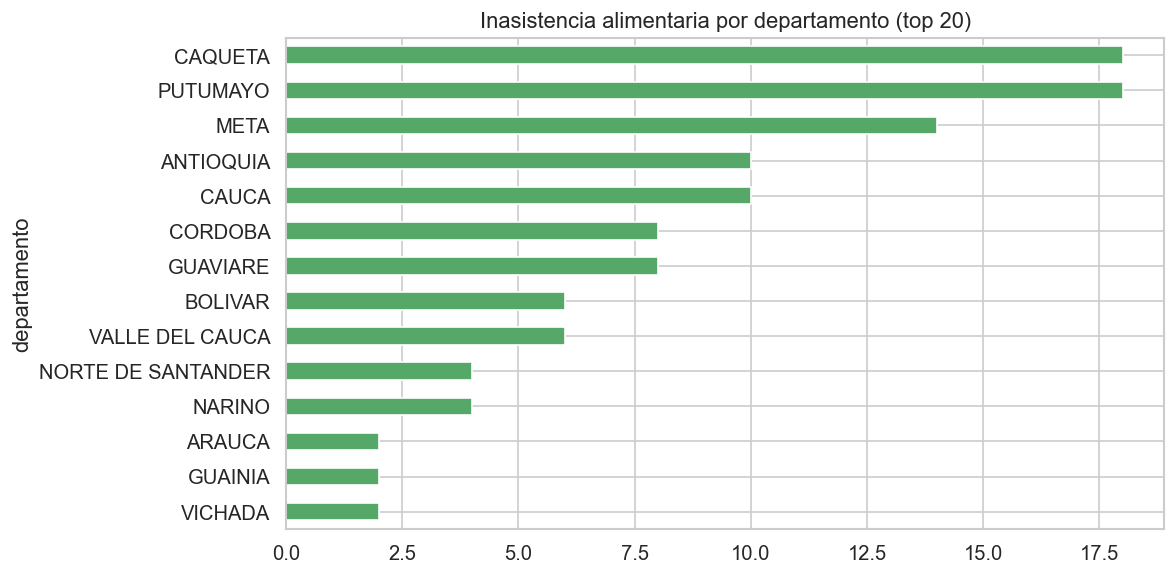

In [9]:
dep_cnt = df.groupby("departamento")["cantidad"].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
dep_cnt.head(20).plot(kind="barh", ax=ax, color="#55A868")
ax.set_title("Inasistencia alimentaria por departamento (top 20)")
ax.invert_yaxis()
plt.tight_layout(); plt.show()


## 6 · Cobertura geográfica

In [10]:
cobertura = sql("""
    SELECT departamento, COUNT(DISTINCT municipio) AS municipios, SUM(cantidad) AS casos
    FROM lexdata.inasistencia_alimentaria
    GROUP BY departamento
    ORDER BY casos DESC
""")
display(cobertura)


,departamento,municipios,casos
0,PUTUMAYO,9,18.0
1,CAQUETA,9,18.0
2,META,7,14.0
3,ANTIOQUIA,5,10.0
4,CAUCA,5,10.0
5,GUAVIARE,4,8.0
6,CORDOBA,4,8.0
7,BOLIVAR,3,6.0
8,VALLE DEL CAUCA,3,6.0
9,NORTE DE SANTANDER,2,4.0


## 7 · Exportar